# Cricket World Cup — Exploratory Data Analysis (EDA)

## 📝 Problem Statement
Cricket is hugely popular across many countries and the Cricket World Cup is its marquee tournament. By analyzing historical World Cup match data, we can uncover patterns in team performances, batting/bowling trends, historical shifts in dominance, and conditions that influence match outcomes. This EDA aims to surface insights useful for fans, analysts, broadcasters, and as a foundation for future predictive modeling.

### 📁 Dataset
[🔗 Source: All Cricket World Cup Match Results (Kaggle)](https://www.kaggle.com/datasets/sidmalang/all-cricket-world-cup-match-result)

### IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

zip_file = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile, os, tempfile, pandas as pd

dfs = {}
filename = list(zip_file.keys())[0]
file_content = zip_file[filename]

with tempfile.NamedTemporaryFile(delete=False) as tmp:
    tmp.write(file_content)
    tmp_path = tmp.name

try:
    with zipfile.ZipFile(tmp_path, 'r') as z:
        for f in z.namelist():
            if f.endswith('.csv'):
                dfs[f] = pd.read_csv(z.open(f))
    # Assign variables dynamically based on file names
    [globals().__setitem__(f"df_{name.split('_')[-1].split('.')[0]}", dfs[f]) for f, name in zip(dfs, dfs.keys())]
finally:
    os.remove(tmp_path)

# CAN ACCESS DATAFRAMES USING THE VARIABLE NAMES AS FOLLOWS:
## df_1975 = dfs['world_cup_1975.csv']
## df_1979 = dfs['world_cup_1979.csv']
## df_1983 = dfs['world_cup_1983.csv']
## df_1987 = dfs['world_cup_1987.csv']
## df_1991 = dfs['world_cup_1991.csv']
## df_1995 = dfs['world_cup_1995.csv']
## df_1999 = dfs['world_cup_1999.csv']
## df_2003 = dfs['world_cup_2003.csv']
## df_2007 = dfs['world_cup_2007.csv']
## df_2011 = dfs['world_cup_2011.csv']
## df_2015 = dfs['world_cup_2015.csv']
## df_2019 = dfs['world_cup_2019.csv']

### DATA PRE PROCESSING

In [ ]:
for year in [1975, 1979, 1983, 1987, 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019]:
    df = globals()[f"df_{year}"]
    print(f"\n df_{year} — Columns:")
    print(list(df.columns))


 df_1975 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_1979 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_1983 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_1987 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_1991 — Columns:
['Id', 'Date', 'Match', 'Ground / Location', 'Result']

 df_1995 — Columns:
['Id', 'Date', 'Match', 'Ground / Location', 'Result']

 df_1999 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_2003 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_2007 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_2011 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_2015 — Columns:
['Id', 'Date', 'Countries', 'Ground', 'Result']

 df_2019 — Columns:
['Id', 'Date', 'Match', 'Ground / Location', 'Result']


RENAMING COLUMNS

In [ ]:
# FOR GROUND COLUMN
df_1991 = df_1991.rename(columns={'Ground / Location': 'Ground'})
df_1995 = df_1995.rename(columns={'Ground / Location': 'Ground'})
df_2019 = df_2019.rename(columns={'Ground / Location': 'Ground'})

# FOR MATCH
df_1975 = df_1975.rename(columns={'Countries': 'Match'})
df_1979 = df_1979.rename(columns={'Countries': 'Match'})
df_1983 = df_1983.rename(columns={'Countries': 'Match'})
df_1987 = df_1987.rename(columns={'Countries': 'Match'})
df_1999 = df_1999.rename(columns={'Countries': 'Match'})
df_2003 = df_2003.rename(columns={'Countries': 'Match'})
df_2007 = df_2007.rename(columns={'Countries': 'Match'})
df_2011 = df_2011.rename(columns={'Countries': 'Match'})
df_2015 = df_2015.rename(columns={'Countries': 'Match'})

In [ ]:
for year in [1975, 1979, 1983, 1987, 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019]:
    df = globals()[f"df_{year}"]
    print(f"\n df_{year} — Columns:")
    print(list(df.columns))


 df_1975 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_1979 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_1983 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_1987 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_1991 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_1995 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_1999 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_2003 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_2007 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_2011 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_2015 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']

 df_2019 — Columns:
['Id', 'Date', 'Match', 'Ground', 'Result']


PRINTING INFO OF EACH DATAFRAME

In [ ]:
for year in [1975, 1979, 1983, 1987, 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019]:
    df = globals()[f"df_{year}"]
    print(f"\n df_{year} — Info:")
    df.info()


 df_1975 — Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Id      15 non-null     int64 
 1   Date    15 non-null     object
 2   Match   15 non-null     object
 3   Ground  15 non-null     object
 4   Result  15 non-null     object
dtypes: int64(1), object(4)
memory usage: 732.0+ bytes

 df_1979 — Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Id      15 non-null     int64 
 1   Date    15 non-null     object
 2   Match   15 non-null     object
 3   Ground  15 non-null     object
 4   Result  15 non-null     object
dtypes: int64(1), object(4)
memory usage: 732.0+ bytes

 df_1983 — Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column  Non-Null Coun

CHANGING DATE COLUMN DATA TYPE


```
object -> datetime64[ns]
```



In [ ]:
# for year in [1975, 1979, 1983, 1987, 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019]:
#     df = globals()[f"df_{year}"]
#     df["Date"] = pd.to_datetime(df["Date"], errors="coerce")  # Convert with error handling

for year in [1975, 1979, 1983, 1987, 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019]:
    df = globals()[f"df_{year}"]
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

MERGING DATAFRAMES

In [ ]:
# Merge all World Cup DataFrames into one
all_wc_df = pd.concat(
    [globals()[f"df_{year}"] for year in [1975, 1979, 1983, 1987, 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019]],
    ignore_index=True
)

print(f"Number of rows in merged dataframe: {all_wc_df.shape[0]}")
print(f"Number of columns in merged dataframe: {all_wc_df.shape[1]}")

Number of rows in merged dataframe: 454
Number of columns in merged dataframe: 5


In [ ]:
all_wc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Id      454 non-null    int64         
 1   Date    454 non-null    datetime64[ns]
 2   Match   454 non-null    object        
 3   Ground  454 non-null    object        
 4   Result  454 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 17.9+ KB


In [ ]:
# # Save the merged DataFrame to a CSV file
# all_wc_df.to_csv("all_world_cups.csv", index=False)
# files.download("all_world_cups.csv")

# print("Dataset saved as all_world_cups.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset saved as all_world_cups.csv


# Exploratory Data Analysis (EDA)

1. Total number of matches played in the dataset.


In [ ]:
print(f"Total number of '{all_wc_df.shape[0]}' matches played in the dataset")

Total number of '454' matches played in the dataset


2. Which team has the highest win percentage?

In [ ]:
df = all_wc_df.copy()

# Split Match column into two teams, handling different formats
df[['Team1', 'Team2']] = df['Match'].str.extract(r'(?:.*?:\s*)?([^v]+)\s*v\.?\s*([^v]+)')

# Function to determine winner
def get_winner(row):
    if pd.isna(row['Result']):
        return None
    result_lower = row['Result'].lower()
    team1_lower = row['Team1'].strip().lower() if pd.notna(row['Team1']) else None
    team2_lower = row['Team2'].strip().lower() if pd.notna(row['Team2']) else None

    if team1_lower and team1_lower in result_lower:
        return row['Team1'].strip()
    elif team2_lower and team2_lower in result_lower:
        return row['Team2'].strip()
    else:
        return None # Handle cases where winner cannot be determined from result string

# Apply function
df['Winner'] = df.apply(get_winner, axis=1)

# Preview result
# print(df[['Match', 'Result', 'Team1', 'Team2', 'Winner']].head())

df['Winner'].value_counts()

,count
Winner,
Australia,72
New Zealand,57
India,53
England,48
West Indies,43
Pakistan,43
Sri Lanka,38
South Africa,38
Bangladesh,14


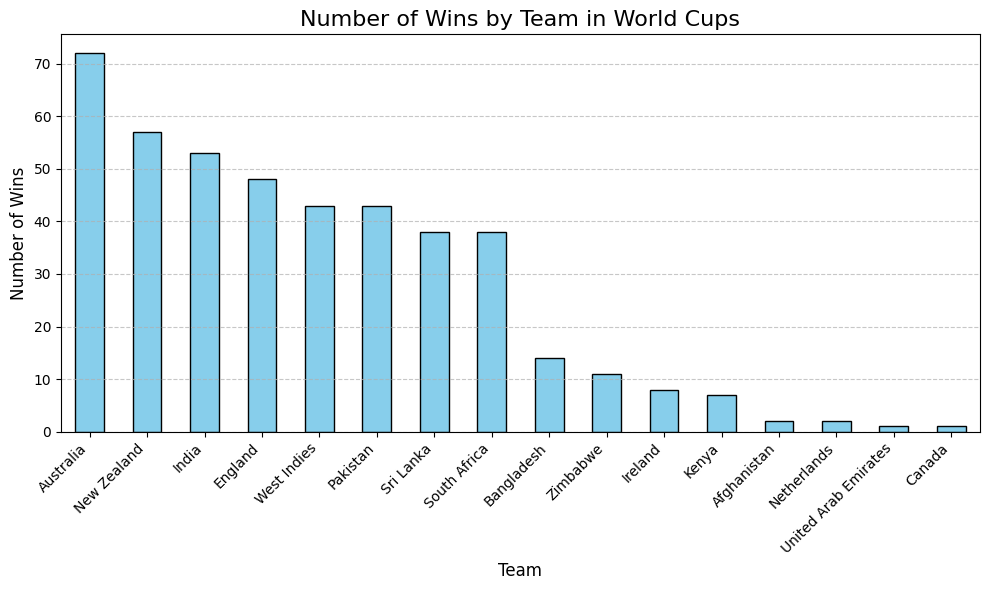

In [ ]:
# Get the win counts
win_counts = df['Winner'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
win_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Title and labels
plt.title('Number of Wins by Team in World Cups', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Show grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

3. Top 5 batsmen by total runs scored. (NOT POSSIBLE AS PER THE PROVIDED DATASET)

4. Top 5 bowlers by total wickets taken. (NOT POSSIBLE AS PER THE PROVIDED DATASET)

5. Average runs scored per match. (NOT POSSIBLE AS PER THE PROVIDED DATASET)

6. Which stadium hosted the most matches?

In [ ]:
# Find stadium with most matches
most_matches_stadium = df['Ground'].value_counts().idxmax()
most_matches_count = df['Ground'].value_counts().max()

print(f"The stadium that hosted the most matches is '{most_matches_stadium}' with {most_matches_count} matches.")

The stadium that hosted the most matches is 'Headingley' with 12 matches.


7. How many matches ended without a result?

In [ ]:
# Count matches without a result (no "won" in the Result column, case-insensitive)
no_result_count = df[~df['Result'].str.contains("won", case=False, na=False)].shape[0]

print(f"Total matches without a result: {no_result_count}")

Total matches without a result: 16


8. Highest team total in the dataset. (NOT POSSIBLE AS PER THE PROVIDED DATASET)

9. Total boundaries (4s and 6s) hit in the tournament. (NOT POSSIBLE AS PER THE PROVIDED DATASET)

10. Visualize runs scored trend by match number.

/tmp/ipython-input-3411522306.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_runs['Match Number'] = range(1, len(df_runs) + 1)


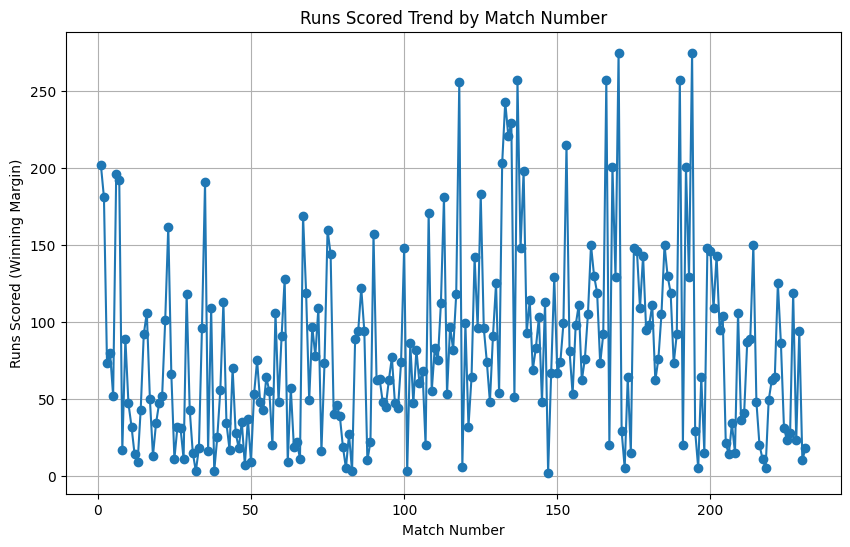

In [ ]:
import re

# Extract runs from Result column (only when it contains 'runs')
df['Runs'] = df['Result'].apply(
    lambda x: int(re.search(r'(\d+)\s+runs', x).group(1)) if pd.notna(x) and 'runs' in x else None
)

# Drop rows without runs data
df_runs = df.dropna(subset=['Runs'])

# Create match number (1 to n)
df_runs['Match Number'] = range(1, len(df_runs) + 1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_runs['Match Number'], df_runs['Runs'], marker='o')
plt.title("Runs Scored Trend by Match Number")
plt.xlabel("Match Number")
plt.ylabel("Runs Scored (Winning Margin)")
plt.grid(True)
plt.show()

> OR

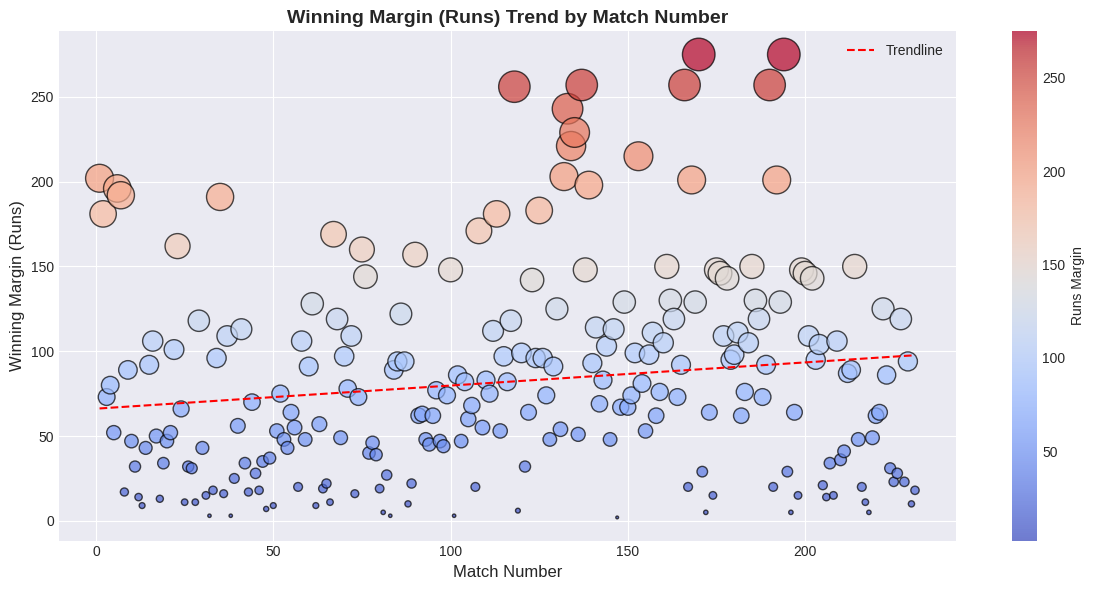

In [ ]:
# Extract runs from Result column
df['Runs'] = df['Result'].apply(
    lambda x: int(re.search(r'(\d+)\s+runs', x).group(1)) if pd.notna(x) and 'runs' in x else None
)

# Drop rows without runs data
df_runs = df.dropna(subset=['Runs']).reset_index(drop=True)
df_runs['Match Number'] = range(1, len(df_runs) + 1)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 6))

# Scatter plot
scatter = plt.scatter(
    df_runs['Match Number'],
    df_runs['Runs'],
    c=df_runs['Runs'],  # Color by runs
    cmap='coolwarm',
    s=df_runs['Runs']*2,  # Size proportional to runs
    alpha=0.7,
    edgecolors='k'
)

# Trendline
z = np.polyfit(df_runs['Match Number'], df_runs['Runs'], 1)
p = np.poly1d(z)
plt.plot(df_runs['Match Number'], p(df_runs['Match Number']), "r--", label="Trendline")

# Labels & title
plt.title("Winning Margin (Runs) Trend by Match Number", fontsize=14, weight='bold')
plt.xlabel("Match Number", fontsize=12)
plt.ylabel("Winning Margin (Runs)", fontsize=12)
plt.colorbar(scatter, label="Runs Margin")
plt.legend()
plt.tight_layout()
plt.show()

# larger circles for higher run margins.
# Used color intensity to indicate magnitude.
# Included a trendline to determine if margins are increasing or decreasing over time.